<a href="https://colab.research.google.com/github/bhavananamburi/oasis-infobyte-internship-/blob/main/Bhavana_task8__Analyzing_Google_Play_Store_Data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 **Loading the Data**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving apps.csv to apps.csv
Saving user_reviews.csv to user_reviews.csv


In [ ]:
apps = pd.read_csv("apps.csv")
reviews = pd.read_csv("user_reviews.csv")

In [ ]:
apps.head()



,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [ ]:
apps.isnull().sum()

,0
Unnamed: 0,0
App,0
Category,0
Rating,1463
Reviews,0
Size,1227
Installs,0
Type,0
Price,0
Content Rating,0


In [ ]:
reviews.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


# Data Cleaning

In [ ]:
apps["Rating"] = apps["Rating"].fillna(apps["Rating"].median())

reviews = reviews.dropna()

apps = apps.drop_duplicates()

reviews = reviews.drop_duplicates()

apps["Reviews"] = pd.to_numeric(apps["Reviews"], errors="coerce")

In [ ]:
apps["Installs"] = apps["Installs"].astype(str)
apps["Installs"] = apps["Installs"].str.replace(",", "")
apps["Installs"] = apps["Installs"].str.replace("+", "")
apps["Installs"] = pd.to_numeric(apps["Installs"], errors="coerce")

In [ ]:
apps["Price"] = apps["Price"].astype(str)
apps["Price"] = apps["Price"].str.replace("$", "", regex=False)
apps["Price"] = pd.to_numeric(apps["Price"], errors="coerce")

In [ ]:
apps["Size"] = apps["Size"].astype(str)
apps["Size"] = apps["Size"].replace("Varies with device", np.nan)
apps["Size"] = apps["Size"].str.replace("M", "", regex=False)
apps["Size"] = apps["Size"].str.replace("k", "", regex=False)
apps["Size"] = pd.to_numeric(apps["Size"], errors="coerce")

In [ ]:
apps.describe()

,Unnamed: 0,Rating,Reviews,Size,Installs,Price
count,9659.000000,8196.000000,9.659000e+03,8432.000000,9.659000e+03,9659.000000
mean,5666.172896,4.173243,2.165926e+05,20.395327,7.777507e+06,1.099299
std,3102.362863,0.536625,1.831320e+06,21.827509,5.375828e+07,16.852152
min,0.000000,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000
25%,3111.500000,4.000000,2.500000e+01,4.600000,1.000000e+03,0.000000
50%,5814.000000,4.300000,9.670000e+02,12.000000,1.000000e+05,0.000000
75%,8327.500000,4.500000,2.940100e+04,28.000000,1.000000e+06,0.000000
max,10840.000000,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000


**Distribution of App Sizes**

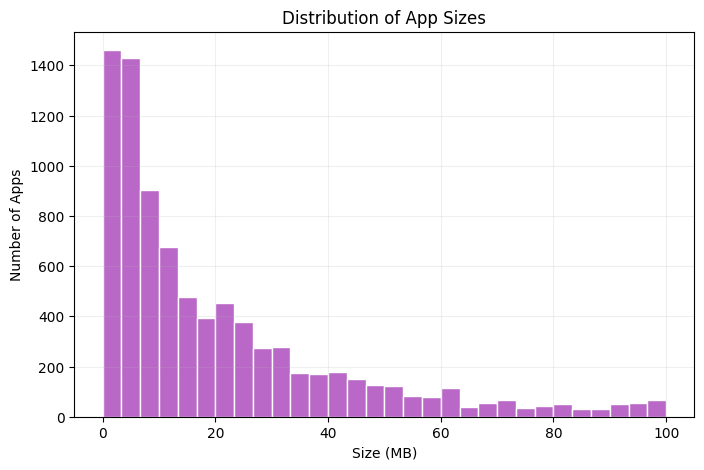

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    apps["Size"].dropna(),
    bins=30,
    color="#BA68C8",
    edgecolor="white"
)

plt.title("Distribution of App Sizes")
plt.xlabel("Size (MB)")
plt.ylabel("Number of Apps")

plt.grid(alpha=0.2)

plt.show()

**GOOGLE PLAY STORE DASHBOARD**

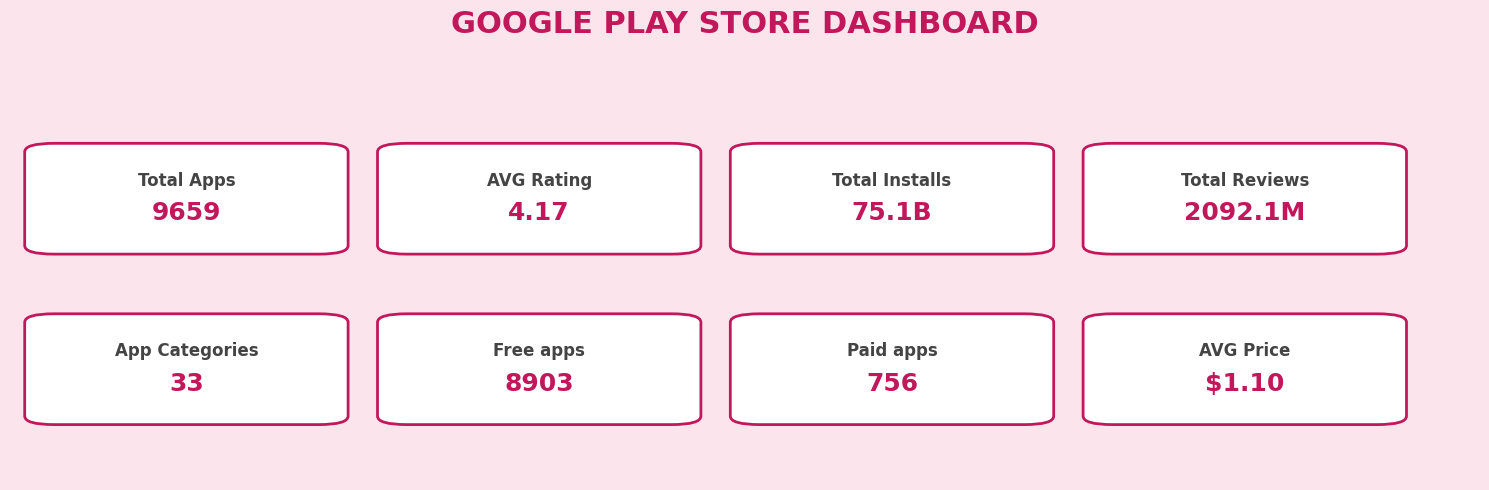

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

kpis = {
    "Total Apps": apps['App'].nunique(),
    "AVG Rating": round(apps['Rating'].mean(),2),
    "Total Installs": f"{apps['Installs'].sum()/1e9:.1f}B",
    "Total Reviews": f"{apps['Reviews'].sum()/1e6:.1f}M",
    "App Categories": apps['Category'].nunique(),
    "Free apps": apps[apps['Type']=='Free'].shape[0],
    "Paid apps": apps[apps['Type']=='Paid'].shape[0],
    "AVG Price": f"${apps['Price'].mean():.2f}"
}

fig, ax = plt.subplots(figsize=(15,5))
fig.patch.set_facecolor('#FCE4EC')
ax.axis('off')

plt.title(
    "GOOGLE PLAY STORE DASHBOARD",
    fontsize=22,
    weight='bold',
    color='#C2185B',
    pad=15
)

for i, (k, v) in enumerate(kpis.items()):
    x = 0.03 + (i % 4) * 0.24
    y = 0.55 if i < 4 else 0.15

    ax.add_patch(FancyBboxPatch(
        (x, y), 0.18, 0.22,
        boxstyle="round,pad=0.02",
        fc="white",
        ec="#C2185B",
        lw=2
    ))

    ax.text(x+0.09, y+0.14, k,
            ha='center', fontsize=12,
            weight='bold', color='#444')

    ax.text(x+0.09, y+0.06, str(v),
            ha='center', fontsize=18,
            weight='bold', color='#C2185B')

plt.tight_layout()
plt.show()

In [ ]:
apps["Category"].value_counts()

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


**Apps by Category**

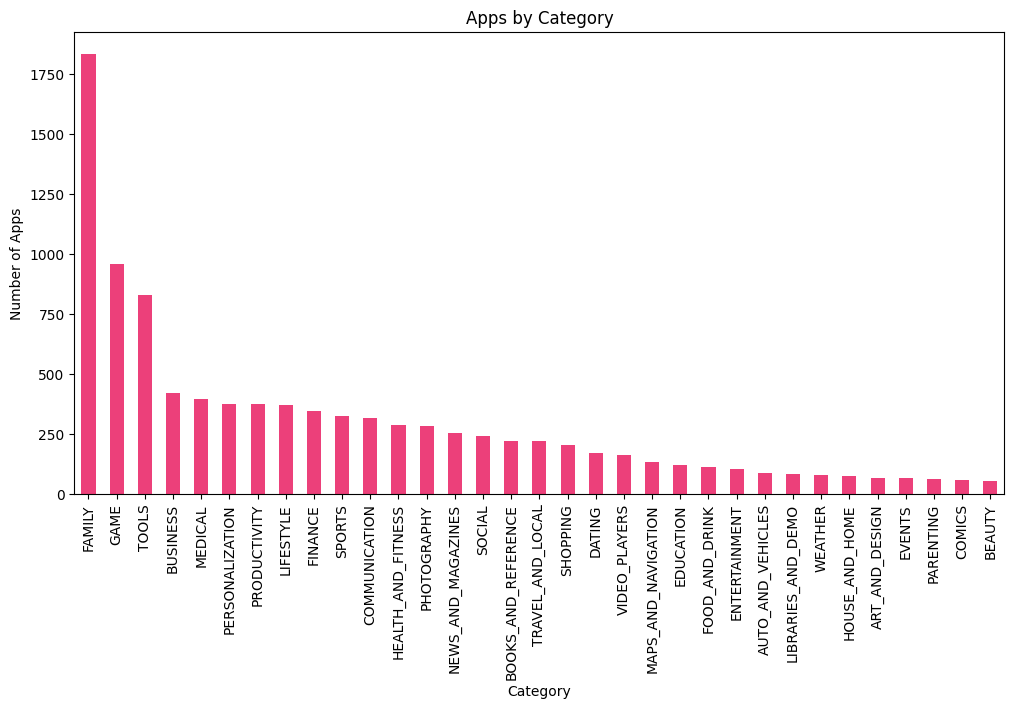

In [ ]:
apps["Category"].value_counts().plot(
    kind="bar",
    figsize=(12,6),
    color='#EC407A'
)

plt.title("Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.show()

**Google Play Store Market Dominance**

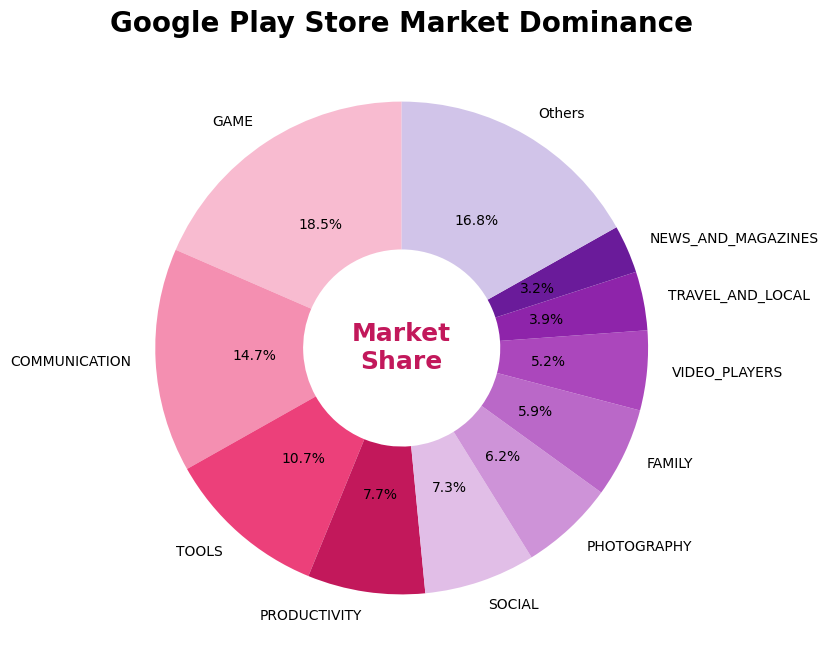

In [ ]:
top = apps.groupby('Category')['Installs'].sum().sort_values(ascending=False)

data = pd.concat([
    top.head(10),
    pd.Series({'Others': top.iloc[10:].sum()})
])

plt.figure(figsize=(8,8))

plt.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors = [
    '#F8BBD0', '#F48FB1', '#EC407A', '#C2185B',
    '#E1BEE7', '#CE93D8', '#BA68C8', '#AB47BC',
    '#8E24AA', '#6A1B9A', '#D1C4E9'
],
    wedgeprops={'width':0.6}
)

plt.text(
    0, 0,
    'Market\nShare',
    ha='center',
    va='center',
    fontsize=18,
    fontweight='bold',
    color='#C2185B'
)

plt.title(
    'Google Play Store Market Dominance',
    fontsize=20,
    fontweight='bold'
)

plt.show()

**Distribution of Ratings**

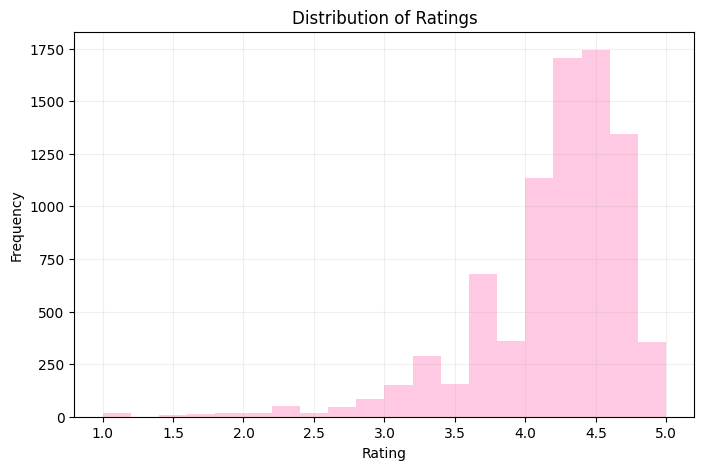

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    apps["Rating"],
    bins=20,
    color='#ffb3d9',
    alpha=0.7,
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.grid(alpha=0.2)
plt.show()

In [ ]:
apps.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(10)

,Rating
Category,
EVENTS,4.435556
EDUCATION,4.364407
ART_AND_DESIGN,4.357377
BOOKS_AND_REFERENCE,4.344970
PERSONALIZATION,4.332215
PARENTING,4.300000
BEAUTY,4.278571
GAME,4.247368
SOCIAL,4.247291


**Top Rated Categories**

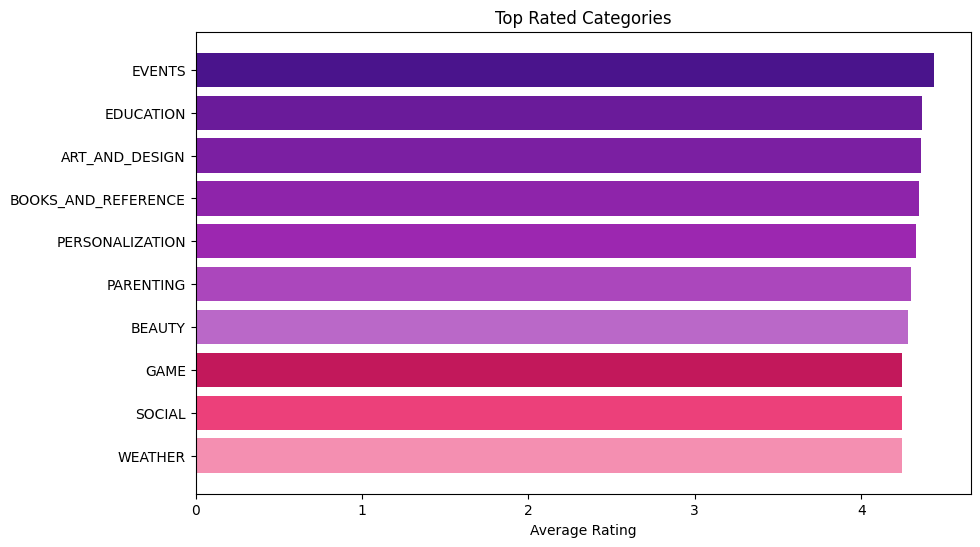

In [ ]:
top_rating = apps.groupby("Category")["Rating"].mean().sort_values().tail(10)

colors = ['#F48FB1', '#EC407A', '#C2185B', '#BA68C8', '#AB47BC',
          '#9C27B0', '#8E24AA', '#7B1FA2', '#6A1B9A', '#4A148C']

plt.figure(figsize=(10,6))

plt.barh(
    top_rating.index,
    top_rating.values,
    color=colors[:len(top_rating)]
)

plt.title("Top Rated Categories")
plt.xlabel("Average Rating")
plt.show()

In [ ]:
apps.sort_values("Installs", ascending=False)[["App", "Installs"]].head(10)

,App,Installs
2977,Google News,1000000000
2012,Google+,1000000000
1356,Subway Surfers,1000000000
152,Google Play Books,1000000000
2908,YouTube,1000000000
2003,Instagram,1000000000
2930,Google Play Movies & TV,1000000000
2191,Google Photos,1000000000
2429,Google Street View,1000000000
701,Google Play Games,1000000000


In [ ]:
apps.sort_values("Reviews", ascending=False)[["App", "Reviews"]].head(10)

,App,Reviews
2002,Facebook,78158306
300,WhatsApp Messenger,69119316
2003,Instagram,66577313
299,Messenger – Text and Video Chat for Free,56642847
1372,Clash of Clans,44891723
3181,Clean Master- Space Cleaner & Antivirus,42916526
1356,Subway Surfers,27722264
2908,YouTube,25655305
6486,"Security Master - Antivirus, VPN, AppLock, Boo...",24900999
1362,Clash Royale,23133508


In [ ]:
apps["Type"].value_counts()

,count
Type,
Free,8903
Paid,756


**Free vs Paid Apps**

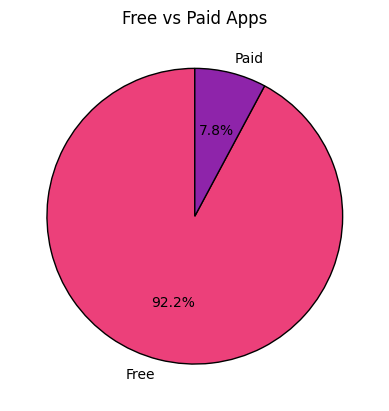

In [ ]:
colors = ['#EC407A', '#8E24AA']

apps["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

plt.ylabel("")
plt.title("Free vs Paid Apps")
plt.show()

In [ ]:
apps.sort_values("Price", ascending=False)[["App", "Price"]].head(10)

,App,Price
3469,I'm Rich - Trump Edition,400.00
4398,I am Rich Plus,399.99
4417,I AM RICH PRO PLUS,399.99
3327,most expensive app (H),399.99
4413,I am Rich,399.99
4400,I Am Rich Premium,399.99
4396,I am rich,399.99
4402,I am Rich!,399.99
4403,I am rich(premium),399.99
8780,I'm Rich/Eu sou Rico/أنا غني/我很有錢,399.99


**Reviews vs Rating**

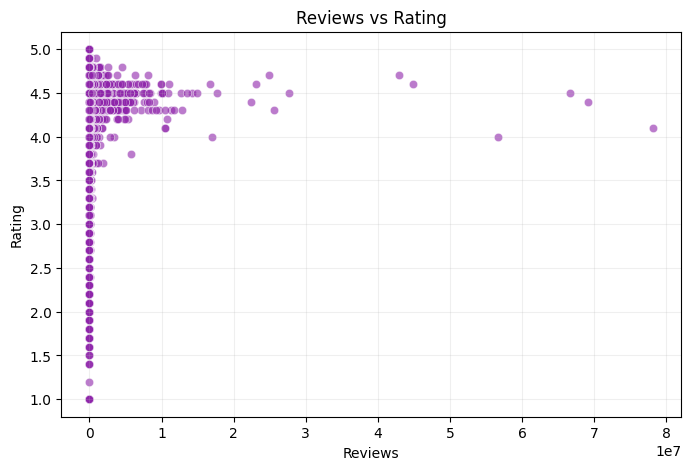

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    apps["Reviews"],
    apps["Rating"],
    color='#8E24AA',
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5
)

plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Rating")

plt.grid(alpha=0.2)
plt.show()

**Installs vs Rating**

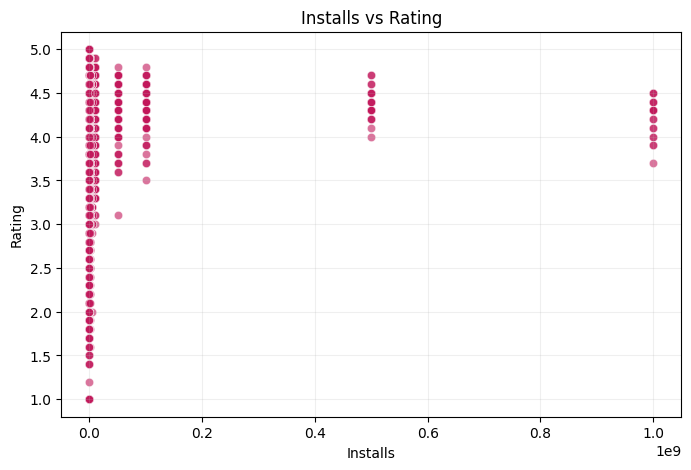

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    apps["Installs"],
    apps["Rating"],
    color='#C2185B',
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5
)

plt.xlabel("Installs")
plt.ylabel("Rating")
plt.title("Installs vs Rating")

plt.grid(alpha=0.2)
plt.show()

In [ ]:
reviews["Sentiment"].value_counts()

,count
Sentiment,
Positive,19015
Negative,6321
Neutral,4361


In [ ]:
reviews["Sentiment_Polarity"].mean()

np.float64(0.18883621991609265)

In [ ]:
apps[["Rating", "Reviews", "Installs", "Price", "Size"]].corr()

,Rating,Reviews,Installs,Price,Size
Rating,1.000000,0.055081,0.040143,-0.021199,0.063076
Reviews,0.055081,1.000000,0.625165,-0.007598,0.179321
Installs,0.040143,0.625165,1.000000,-0.009405,0.134291
Price,-0.021199,-0.007598,-0.009405,1.000000,-0.022434
Size,0.063076,0.179321,0.134291,-0.022434,1.000000


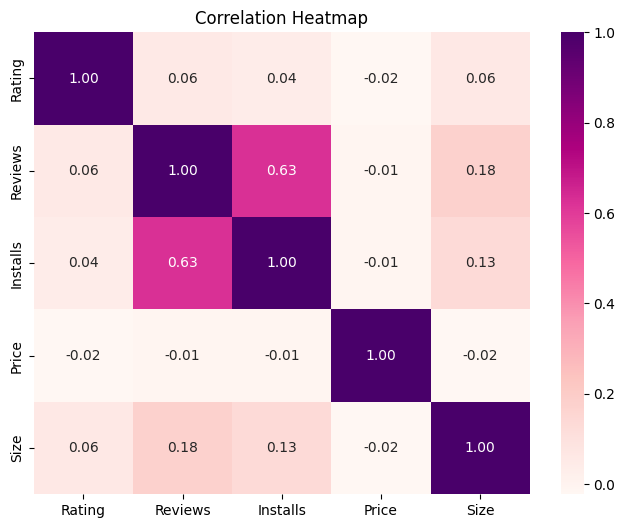

In [ ]:
corr = apps[["Rating", "Reviews", "Installs", "Price", "Size"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='RdPu',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print(apps.dtypes)

Unnamed: 0          int64
App                object
Category           object
Rating            float64
Reviews             int64
Size              float64
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


**Top 8 Categories by Installs**

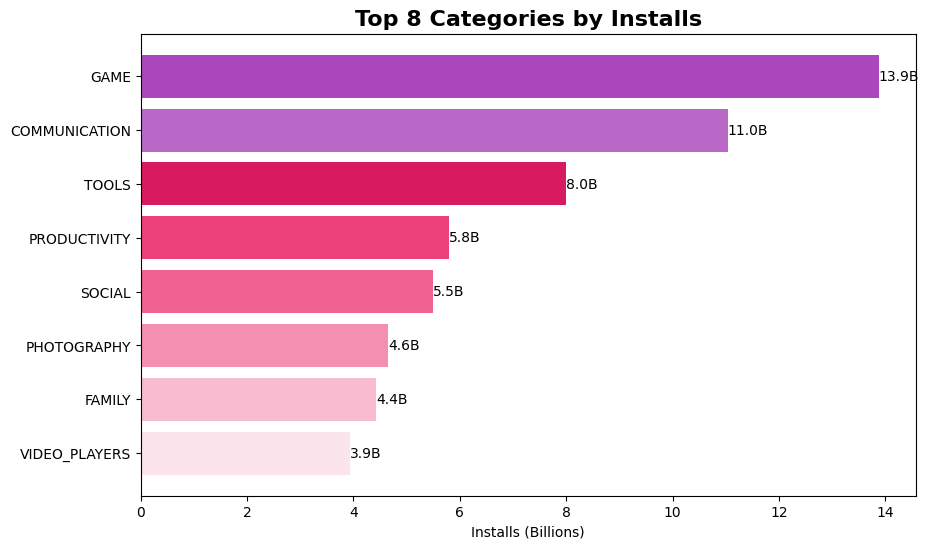

In [ ]:
colors = [
    '#FCE4EC', '#F8BBD0', '#F48FB1',
    '#F06292', '#EC407A', '#D81B60',
    '#BA68C8', '#AB47BC', '#8E24AA'
]

top8 = (apps.groupby('Category')['Installs']
        .sum()
        .sort_values(ascending=True)
        .tail(8))

plt.figure(figsize=(10,6))

plt.barh(
    top8.index,
    top8.values/1e9,
    color=colors
)

plt.title('Top 8 Categories by Installs',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Installs (Billions)')

for i, v in enumerate(top8.values/1e9):
    plt.text(v, i, f'{v:.1f}B', va='center')

plt.show()

**USER REVIEW**

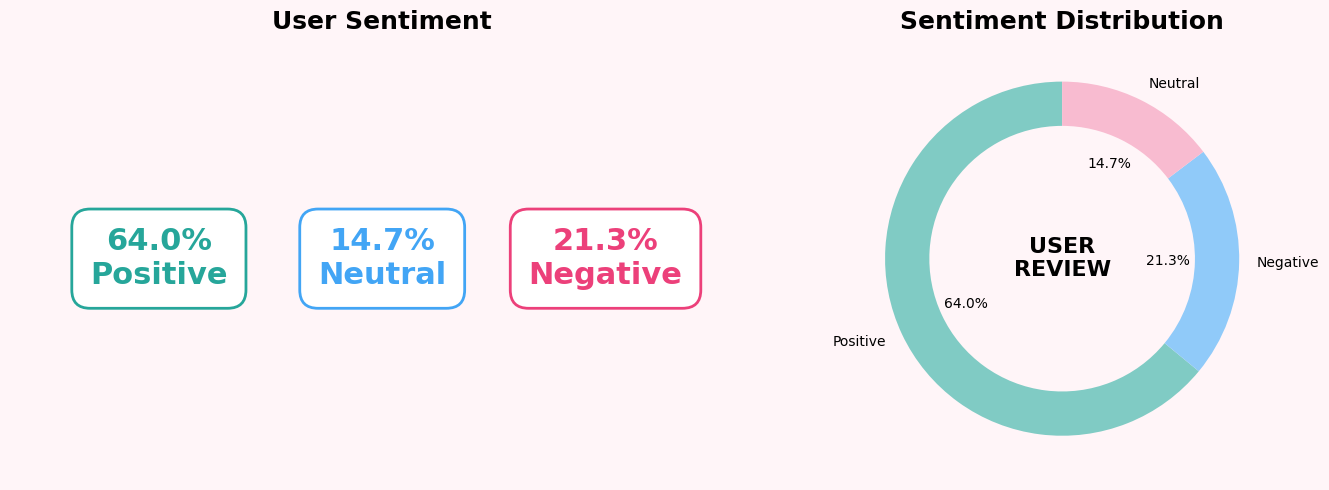

In [ ]:
sent = reviews['Sentiment'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(
    1, 2,
    figsize=(14,5),
    gridspec_kw={'width_ratios':[1.2,1]}
)

fig.patch.set_facecolor('#FFF5F8')

ax[0].axis('off')

cards = [
    ('Positive', sent.get('Positive',0), '#26A69A'),
    ('Neutral', sent.get('Neutral',0), '#42A5F5'),
    ('Negative', sent.get('Negative',0), '#EC407A')
]

for i, (label, val, color) in enumerate(cards):
    ax[0].text(
        0.2 + i*0.3, 0.5,
        f'{val:.1f}%\n{label}',
        ha='center',
        va='center',
        fontsize=22,
        color=color,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.6',
            facecolor='white',
            edgecolor=color,
            linewidth=2
        )
    )

ax[0].set_title(
    'User Sentiment',
    fontsize=18,
    fontweight='bold'
)

counts = reviews['Sentiment'].value_counts()

ax[1].pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors = ['#80CBC4', '#90CAF9', '#F8BBD0'],
    wedgeprops={'width':0.25}
)

ax[1].text(
    0, 0,
    'USER\nREVIEW',
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold'
)

ax[1].set_title(
    'Sentiment Distribution',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**KEY FINDINGS:**

➜ The average app rating is 4.01/5

➜ Total app installs are around 59.42 billion

➜ About 71.1% of the apps are free

➜ Entertainment is the most popular category based on installs

➜ More than half (55.3%) of the user reviews are positive




**RECOMMENDATIONS:**

➜ Developers should focus on popular categories like Entertainment.

➜ Offering free apps with premium features can attract more users.

➜ User feedback should be considered to improve app quality.

➜ Keeping the app lightweight and easy to use can improve the user experience.